# Libraries

In [128]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import plot_grouped_bar_by_columns, plot_single_bar_metric, plot_rank_comparison, plot_multi_rank_comparison


# Evaluating FIREBENCH Benchmarks 

Here we will evaluate the raw query metrics returned by Firebench. These raw metrics were calculated using [Firebench](https://huggingface.co/datasets/sagecontinuum/FireBench) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-3-27b-it](https://huggingface.co/google/gemma-3-27b-it), and set to **response_limit=25**. This means it will return up to 25 images. This was configured this way to match production deployment.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.
>NOTE: Firebench does not have a leaderboard at the moment, this is the first time this benchmark was ran.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-3-27b-it` integrated which included:

- **gemma-3-27b-it for Caption Generation**: Captions are generated for images using the gemma-3-27b-it model.
- **Vector Search**: Utilizes embeddings of both the images and their captions to perform semantic search on **CLIP's** imbedding space.
- **Keyword Search**: Searches are also performed using keywords extracted from image captions.
- **Hybrid Search**: A combination of vector and keyword searches to return the most relevant results.
- **[ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) for Reranker**: A model that refines the order of search results, ensuring that the most relevant documents or items are ranked higher. It goes beyond the initial retrieval step, considering additional factors such as semantic similarity, context, and other relevant features.

Here were the Hyperparameters used for the image search:

In [129]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'alpha': 0.4, 'query_properties': ['caption']...",dict
1,firebench_dataset,sagecontinuum/FireBench,str
2,gemma3_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
3,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
4,hnsw_ef,-1,int
5,hnsw_ef_construction,100,int
6,hnsw_ef_factor,20,int
7,hnsw_flatSearchCutoff,40000,int
8,hnsw_maxConnections,50,int
9,hnsw_quantizer,enabled=True bitCompression=None centroids=Non...,_PQConfigCreate


## Query and Image Collection Process

This explanation was grabbed from the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) in huggingface so that we can better understand the results in further sections.

### Query Collection

Queries in FireBench are **natural-language descriptions of wildfire phenomena**, written to reflect how fire scientists would search for imagery. They are not manually authored by humans; instead they are **generated by an AI text model (OpenAI, GPT-5-mini) from seed images**.

**Process:**

1. **Seed images** — A fixed number of seed images (controlled by the `FIREBENCH_NUM_SEEDS` hyperparameter) are selected from the candidate image pool.
2. **Query generation** — For each seed, the text API is given the image (and any associated context) and is prompted to produce a natural-language query that a fire scientist might use to find that kind of scene. The model is instructed to adopt a fire-scientist perspective so the queries reflect realistic search intents (e.g., "Fixed long-range daytime webcam images of mountainous shrubland with no visible smoke or flames").
3. **One query per seed** — Each generated query is assigned a unique `query_id` (e.g. `firebench_q001`, `firebench_q002`) and is then used to retrieve and label candidate images.

The result is a set of **expert-style queries** over wildfire imagery that support evaluation of text-to-image retrieval, relevance classification, and robustness to confounders (e.g., fog, haze, clouds). For full pipeline details and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the `config_values.csv` in the benchmark's `summary/` directory.


### Image Annotation

FireBench annotates images in two main ways: **vision-based description** of each image, and **relevance labeling** for each query–image pair. Both are automated with AI models (OpenAI APIs), not human annotators.

**1. Vision annotation (per image)**  
Each image is processed with **OpenAI’s vision API (GPT-5-mini)** to produce:

- **Summary** — A short factual description (≤30 words).
- **Categorical facets** — From fixed taxonomies: `viewpoint` (e.g. fixed_long_range, handheld, aerial), `plume_stage` (e.g. none, developing, mature), `lighting` (e.g. day, night, ir_nir), `confounder_type` (e.g. none, haze, cloud, sun_glare), and `environment_type` (e.g. mountainous, forest, shrubland).
- **Controlled vocabulary tags** — Typically 12–18 tags per image (e.g. no_smoke_visible, daylight, sky_dominant, foreground_terrain).
- **Confidence scores** — For each categorical facet, a score between 0 and 1.

**2. Relevance labeling (per query–image pair)**  
For each query, candidate images are scored as **relevant (1)** or **not relevant (0)** by an **AI judge** using OpenAI’s text API (GPT-5-mini), prompted to reflect fire-scientist criteria. This yields the binary `relevance_label` used for retrieval metrics.

**3. CLIPScore (per query–image pair)**  
A **CLIP similarity score** between the query text and the image is computed offline using the model `apple/DFN5B-CLIP-ViT-H-14-378` and stored in the dataset as `clip_score`.

For annotation prompts and hyperparameters (e.g. `VISION_ANNOTATION_*`, `JUDGE_*`), see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the benchmark’s `summary/config_values.csv`.


### Query Categories

FireBench does not assign each query to a single category. Instead, **queries are characterized by the same metadata dimensions used for images**, so that retrieval can be analyzed (and evaluated) along fire-science-relevant axes. Each query–image pair has metadata from these **locked taxonomies** (defined in the dataset creation config):

- **viewpoint** — How the scene was captured (e.g. `fixed_long_range`, `handheld`, `aerial`).
- **plume_stage** — Smoke-plume stage when relevant (e.g. `none`, `incipient`, `developing`, `mature`).
- **lighting** — Conditions (e.g. `day`, `dusk`, `night`, `ir_nir`).
- **confounder_type** — Confounders that can cause false positives (e.g. `none`, `haze`, `cloud`, `fog_marine_layer`, `sun_glare`).
- **environment_type** — Setting (e.g. `mountainous`, `forest`, `shrubland`).
- **flame_visible** — Whether flames are visible in the image (boolean).

Queries therefore span **clear/baseline conditions** (no smoke or flames), **smoke and plume conditions** (various stages), and **confounder-heavy conditions** (haze, clouds, etc.), so the benchmark can measure both recall of relevant fire imagery and robustness against false positives. For the exact taxonomy values, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the benchmark’s `summary/config_values.csv` (e.g. `VIEWPOINT`, `PLUME_STAGE`, `LIGHTING`, `CONFOUNDER`, `ENVIRONMENT`).

### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/FireBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/FireBench/resolve/main/summary/image_proportion_donuts.png)

## Exploratory Data Analysis

The dataset provides an EDA of the data. If you are interested in finding out more analytical information about the data, please refer to it.

[Firebench EDA](https://huggingface.co/datasets/sagecontinuum/FireBench/blob/main/summary/firebench_eda_analysis.ipynb)
>NOTE: The EDA can be used along side these evaluation metrics to better understand the results.

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries created by the INQUIRE authors.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: 1 if atleast one relevant image was returned. Take the average of this metric to get the hit rate which is the percentage of queries that had at least one relevant image returned in the top k images (k = response limit).
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rr**: The reciprocal rank of the rerank scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column clip_rr.
- **clip_rr**: The reciprocal rank of the clip scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column rr. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If rr is higher than this column, that means our image search system is doing better.
- **environment_type**: The environment type of the original image the query was generated from.
- **confounder_type**: The confounder type of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **flame_visible**: Whether the original image the query was generated from has a flame visible.
- **plume_stage**: The plume stage of the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.


In [130]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,NDCG,clip_NDCG,rr,clip_rr,environment_type,confounder_type,lighting,flame_visible,plume_stage,viewpoint
0,firebench_q001,Fixed long-range daytime webcam images of moun...,25,1,24,1,24,0.04,0.04,0.027778,...,0.777864,0.970324,1.0,1.0,mountainous,none,day,False,none,fixed_long_range
1,firebench_q002,Clear daytime fixed long-range (summit/mountai...,25,2,23,2,23,0.08,0.08,0.055556,...,0.772931,0.974343,0.5,1.0,mountainous,none,day,False,none,fixed_long_range
2,firebench_q003,Daytime fixed-mount long-range mountain webcam...,25,0,25,0,25,0.00,0.00,0.000000,...,0.903487,0.983132,1.0,1.0,mountainous,none,day,False,none,fixed_long_range
3,firebench_q004,Long-range daytime webcam images of a single c...,25,3,22,2,23,0.12,0.08,0.200000,...,0.680390,0.886452,0.5,1.0,shrubland,none,day,False,developing,fixed_long_range
4,firebench_q005,Daytime fixed long-range camera views of dry s...,25,0,25,0,25,0.00,0.00,0.000000,...,0.884331,0.995974,1.0,1.0,mountainous,none,day,False,none,fixed_long_range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,firebench_q096,Dusk long-range mountain/webcam images showing...,25,1,24,1,24,0.04,0.04,0.038462,...,0.825422,0.942463,1.0,1.0,mountainous,cloud,dusk,False,none,fixed_long_range
96,firebench_q097,Aerial top-down daytime images of mixed/decidu...,25,7,18,6,19,0.28,0.24,0.666667,...,0.689925,0.954116,0.5,1.0,forest,none,day,False,none,aerial
97,firebench_q098,Daytime fixed long-range webcam images of moun...,25,3,22,1,24,0.12,0.04,0.028571,...,0.826648,0.926145,1.0,1.0,mountainous,haze,day,False,none,fixed_long_range
98,firebench_q099,Dusk/dawn long-range mountain-valley webcam ph...,25,2,23,1,24,0.08,0.04,0.076923,...,0.914028,0.977965,1.0,1.0,mountainous,fog_marine_layer,dusk,False,none,fixed_long_range


## Overall Metrics
First, we will begin with evaluating all queries.

In [131]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")

total_images: 2500
correctly_returned: 216
incorrectly_returned: 2284
relevant_images: 154
non_relevant_images: 2346
accuracy: 0.08639999999999999
precision: 0.0616
recall: 0.11715332806490088
hit_rate: 0.67
NDCG: 0.7888963955016837
clip_NDCG: 0.9103008873128151
mrr: 0.7286666666666666
clip_mrr: 0.9236666666666667

Insights:
The system returned a total of 216 correct images out of 2500 total images returned.
The accuracy of the system is 0.0864, indicating that 8.64% of the returned images correctly matched with the query.
The precision of the system is 0.0616, indicating that 6.16% of the total images returned were relevant images.
The recall of the system is 0.1172, indicating that 11.72% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.6700, indicating that 67.00% of the total queries processed had at least one relevant image.
The NDCG score is 0.7889, and the Clip NDCG score is 0.9103, indicating the ranking quality of the returned images a

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [132]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,coastal,50,10,40,4,46,0.200000,0.080000,0.583333,1.000000,0.845929,0.947017,0.750000,1.000000
1,forest,1000,93,907,72,928,0.093000,0.072000,0.129001,0.700000,0.785726,0.892488,0.715556,0.913333
2,grassland,200,12,188,4,196,0.060000,0.020000,0.065270,0.375000,0.778418,0.885010,0.729167,0.895833
3,mountainous,950,91,859,66,884,0.095789,0.069474,0.114823,0.736842,0.789366,0.931397,0.740205,0.947368
4,other,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.609665,0.904201,0.250000,1.000000
5,shrubland,200,8,192,6,194,0.040000,0.030000,0.055326,0.625000,0.790558,0.958576,0.691667,1.000000
6,unknown,75,2,73,2,73,0.026667,0.026667,0.020202,0.333333,0.870449,0.796856,1.000000,0.555556


### Accuracy

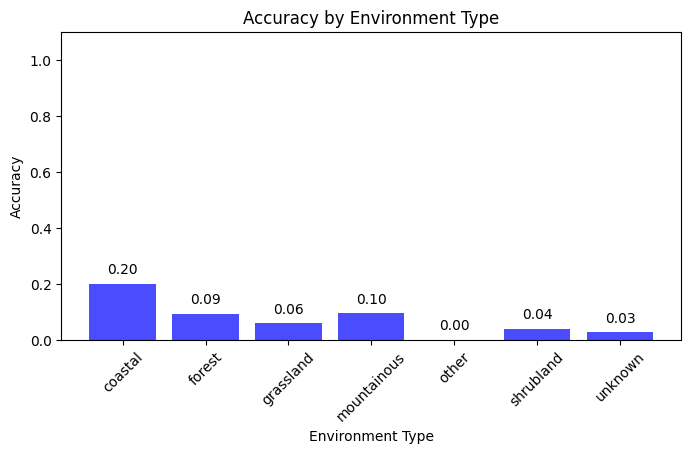

In [133]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

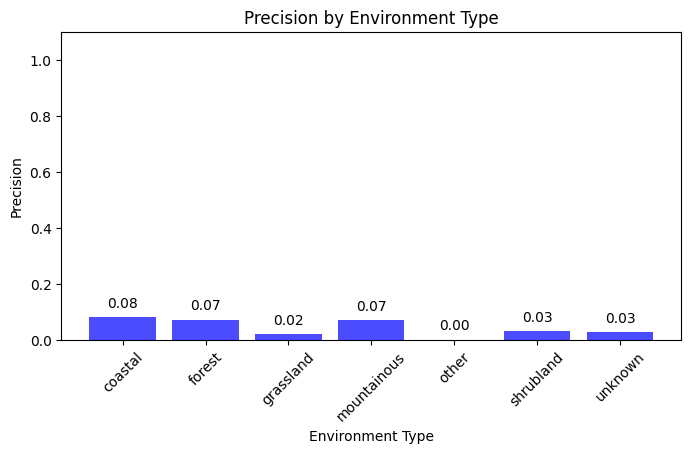

In [134]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

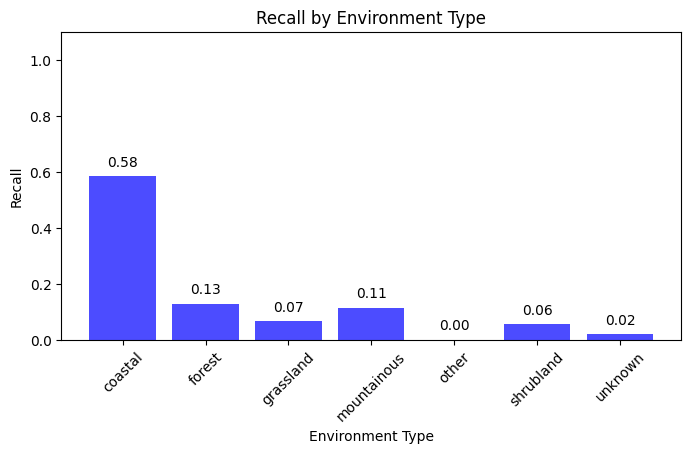

In [135]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

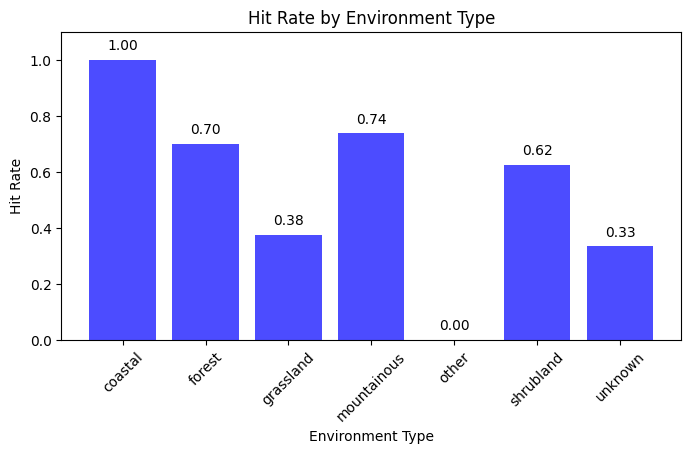

In [136]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### NDCG

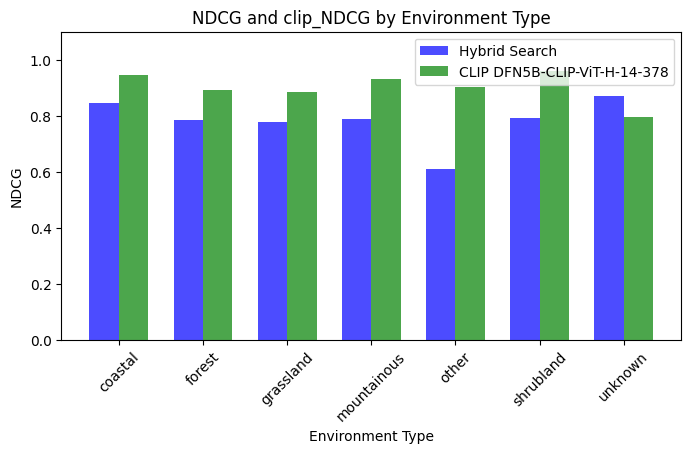

In [137]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

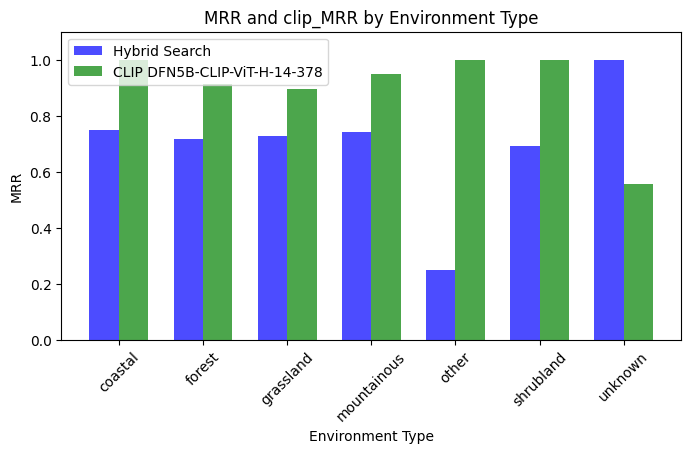

In [138]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Confounder Type

In [139]:
# Group by confounder type and calculate the sum/mean of each metric
confounder_metrics = df.groupby('confounder_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
confounder_metrics = confounder_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

confounder_metrics

,confounder_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,cloud,600,48,552,37,563,0.080000,0.061667,0.085934,0.625000,0.814242,0.888915,0.765278,0.875000
1,fog_marine_layer,475,56,419,43,432,0.117895,0.090526,0.151845,0.736842,0.798476,0.937588,0.663743,0.973684
2,haze,250,20,230,11,239,0.080000,0.044000,0.157173,0.500000,0.777251,0.940614,0.731111,1.000000
3,none,950,71,879,49,901,0.074737,0.051579,0.104375,0.684211,0.784214,0.923785,0.750439,0.960526
4,sun_glare,175,19,156,12,163,0.108571,0.068571,0.167043,0.857143,0.696035,0.809881,0.580159,0.719048
5,unknown,50,2,48,2,48,0.040000,0.040000,0.030303,0.500000,0.865946,0.851404,1.000000,0.666667


### Accuracy

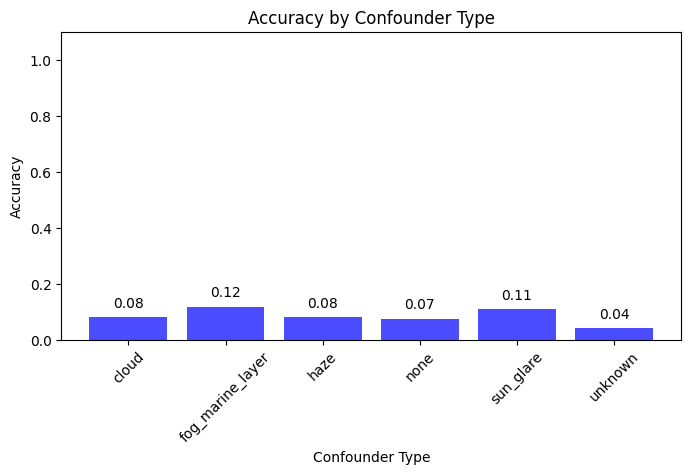

In [140]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='accuracy', title='Accuracy by Confounder Type', ylabel='Accuracy', xlabel='Confounder Type')

### Precision

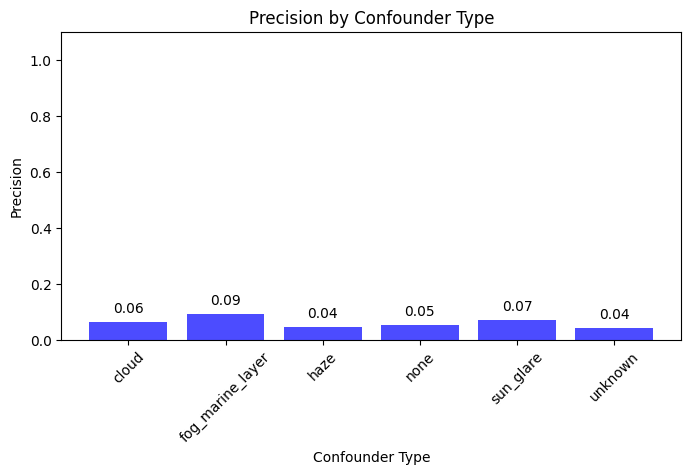

In [141]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='precision', title='Precision by Confounder Type', ylabel='Precision', xlabel='Confounder Type')

### Recall

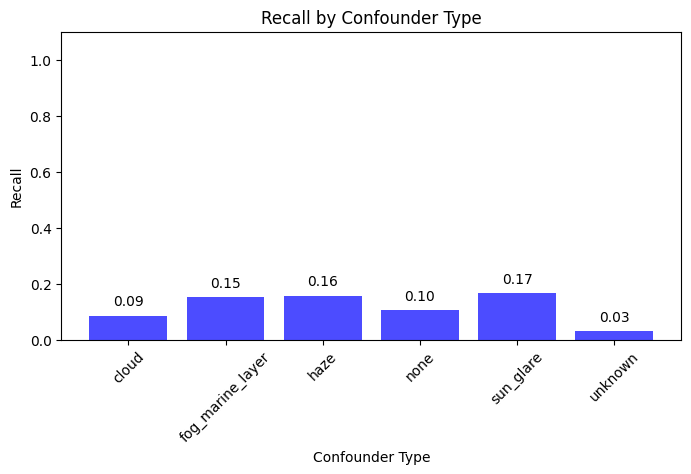

In [142]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='recall', title='Recall by Confounder Type', ylabel='Recall', xlabel='Confounder Type')

### Hit Rate

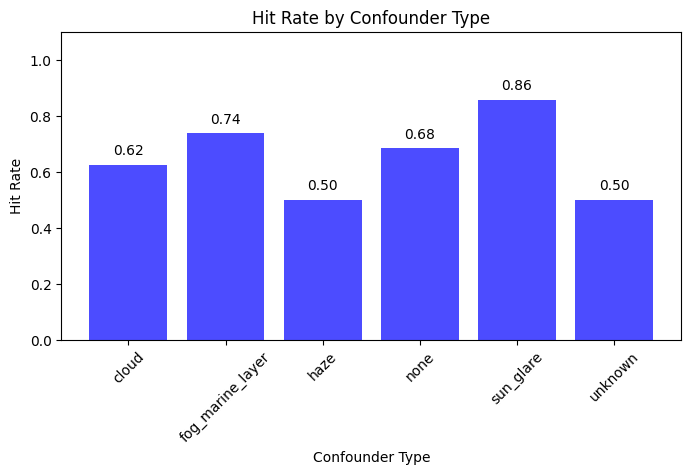

In [143]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='hit_rate', title='Hit Rate by Confounder Type', ylabel='Hit Rate', xlabel='Confounder Type')

### NDCG

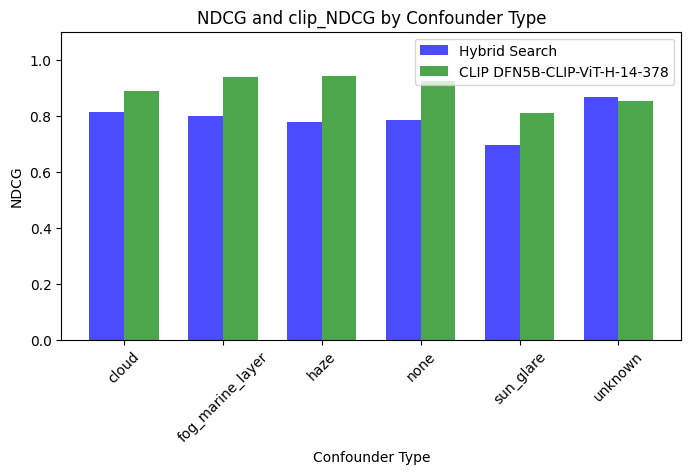

In [144]:
plot_rank_comparison(confounder_metrics, x_column='confounder_type', title='NDCG and clip_NDCG by Confounder Type', xlabel='Confounder Type')

### MRR

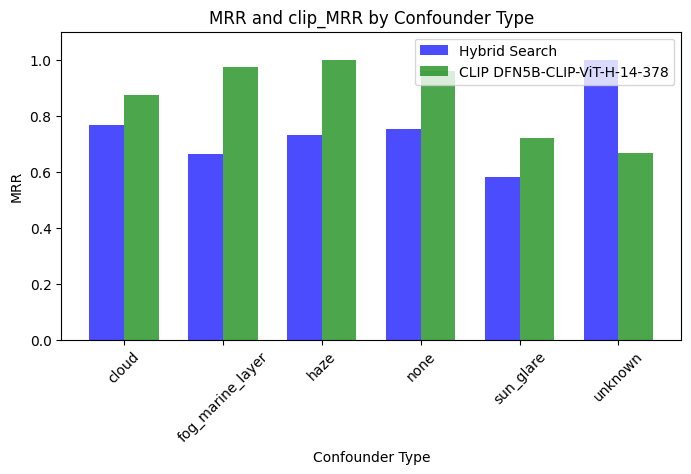

In [145]:
plot_rank_comparison(confounder_metrics, x_column='confounder_type', title='MRR and clip_MRR by Confounder Type', xlabel='Confounder Type', metric="MRR")

## Metrics based on Lighting

In [146]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,day,1975,148,1827,109,1866,0.074937,0.05519,0.104984,0.64557,0.794846,0.920108,0.723980,0.943038
1,dusk,200,31,169,20,180,0.155000,0.10000,0.219036,1.00000,0.738412,0.834752,0.726389,0.775000
2,ir_nir,75,1,74,0,75,0.013333,0.00000,0.000000,0.00000,0.900023,0.790531,1.000000,0.555556
3,night,250,36,214,25,225,0.144000,0.10000,0.166931,0.80000,0.748946,0.929191,0.686111,1.000000


In [147]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

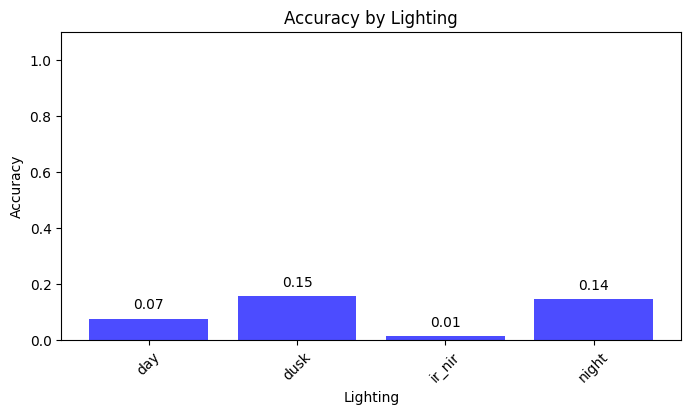

In [148]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

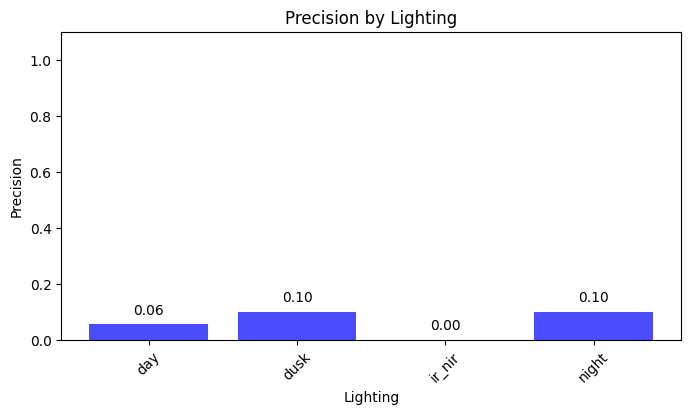

In [149]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

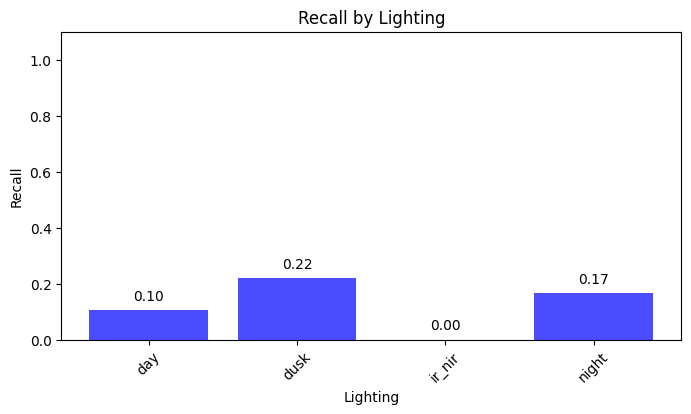

In [150]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

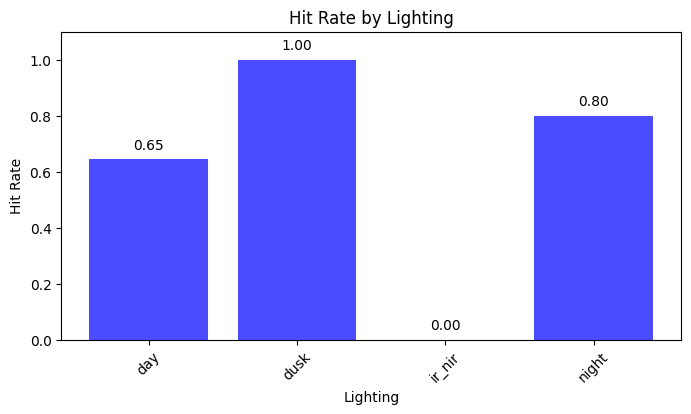

In [151]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### NDCG

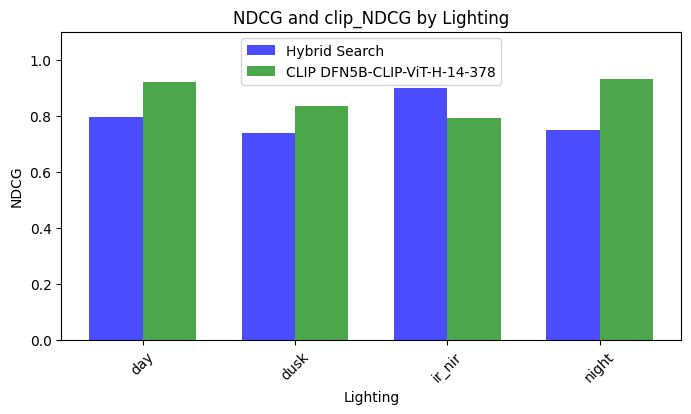

In [152]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

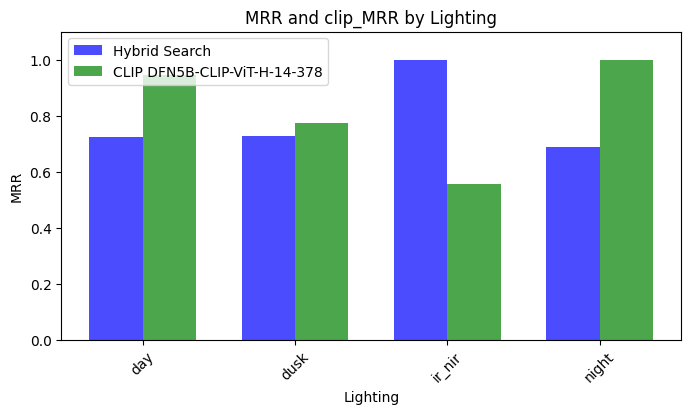

In [153]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Flame Visible

In [154]:
# Group by flame visible and calculate the sum/mean of each metric
flame_visible_metrics = df.groupby('flame_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
flame_visible_metrics = flame_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# use true and false instead of 1 and 0
flame_visible_metrics['flame_visible'] = flame_visible_metrics['flame_visible'].map({True: 'True', False: 'False'})
flame_visible_metrics

,flame_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,False,2350,192,2158,140,2210,0.081702,0.059574,0.111001,0.659574,0.797028,0.911037,0.738475,0.924113
1,True,150,24,126,14,136,0.160000,0.093333,0.213545,0.833333,0.661503,0.898769,0.575000,0.916667


### Accuracy

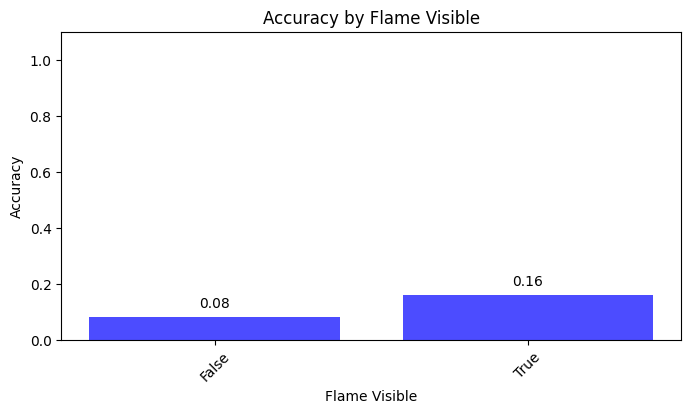

In [155]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='accuracy', title='Accuracy by Flame Visible', ylabel='Accuracy', xlabel='Flame Visible')

### Precision

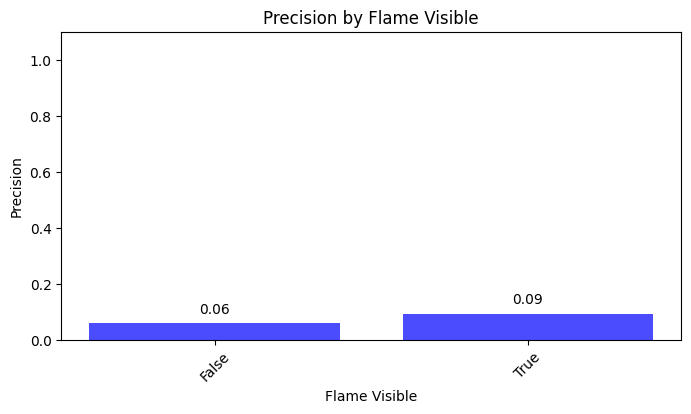

In [156]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='precision', title='Precision by Flame Visible', ylabel='Precision', xlabel='Flame Visible')

### Recall

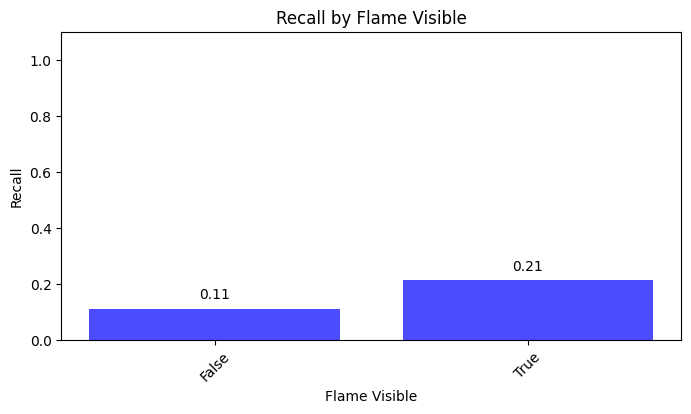

In [157]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='recall', title='Recall by Flame Visible', ylabel='Recall', xlabel='Flame Visible')

### Hit Rate

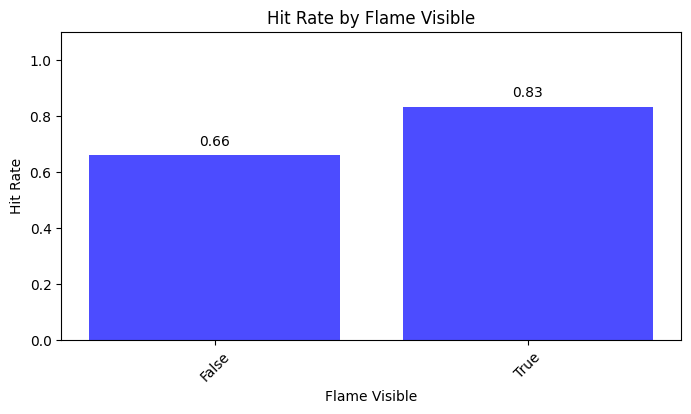

In [158]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='hit_rate', title='Hit Rate by Flame Visible', ylabel='Hit Rate', xlabel='Flame Visible')

### NDCG

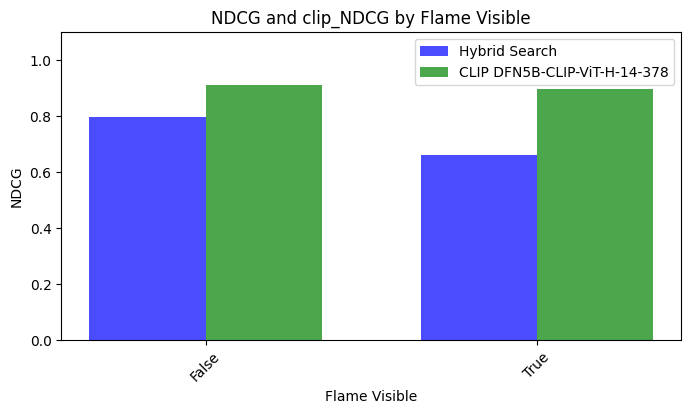

In [159]:
plot_rank_comparison(flame_visible_metrics, x_column='flame_visible', title='NDCG and clip_NDCG by Flame Visible', xlabel='Flame Visible')

### MRR

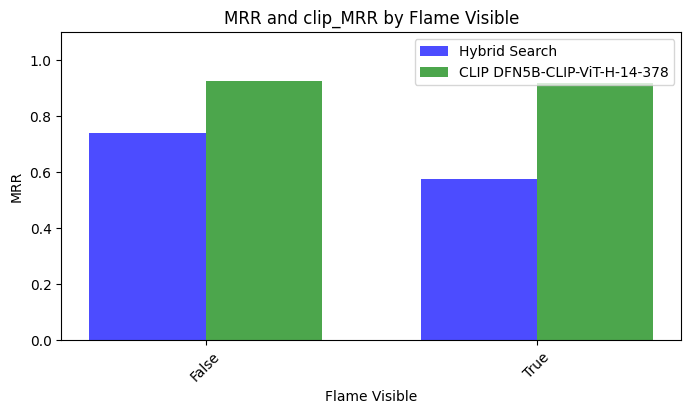

In [160]:
plot_rank_comparison(flame_visible_metrics, x_column='flame_visible', title='MRR and clip_MRR by Flame Visible', xlabel='Flame Visible', metric="MRR")

## Metrics based on Plume Stage

In [161]:
# Group by plume stage and calculate the sum/mean of each metric
plume_stage_metrics = df.groupby('plume_stage').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
plume_stage_metrics = plume_stage_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

plume_stage_metrics

,plume_stage,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,developing,600,45,555,29,571,0.075000,0.048333,0.078047,0.708333,0.796144,0.878293,0.769907,0.833333
1,incipient,100,3,97,2,98,0.030000,0.020000,0.031944,0.500000,0.717477,0.839502,0.652778,0.800000
2,mature,400,39,361,26,374,0.097500,0.065000,0.145341,0.625000,0.742875,0.899684,0.663542,0.968750
3,none,1325,108,1217,81,1244,0.081509,0.061132,0.113702,0.660377,0.800879,0.933280,0.729455,0.965409
4,residual,50,15,35,11,39,0.300000,0.220000,0.324242,1.000000,0.822171,0.898454,0.750000,0.750000
5,unknown,25,6,19,5,20,0.240000,0.200000,0.714286,1.000000,0.935349,0.937377,1.000000,1.000000


### Accuracy

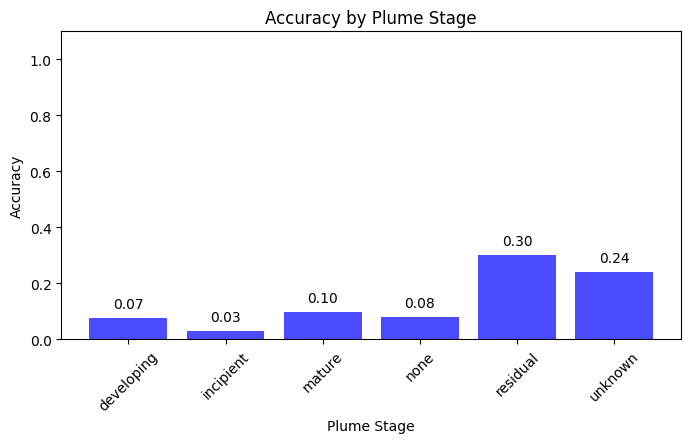

In [162]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='accuracy', title='Accuracy by Plume Stage', ylabel='Accuracy', xlabel='Plume Stage')

### Precision

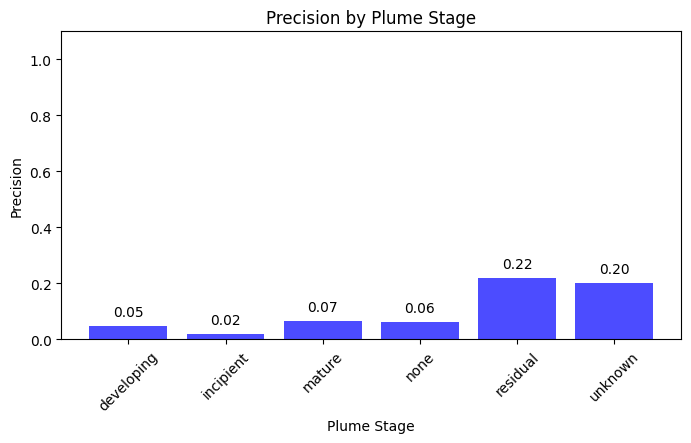

In [163]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='precision', title='Precision by Plume Stage', ylabel='Precision', xlabel='Plume Stage')

### Recall

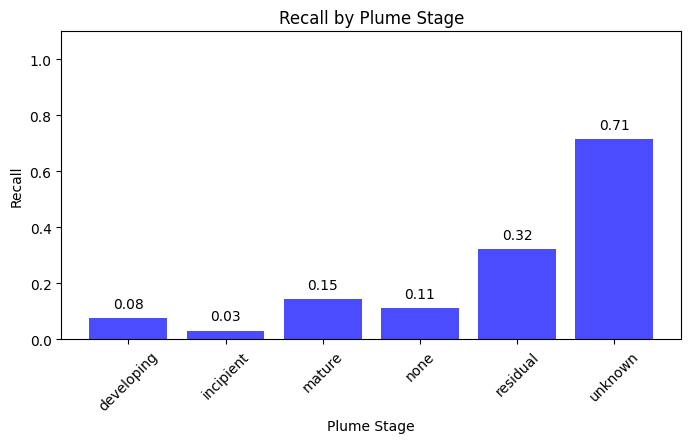

In [164]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='recall', title='Recall by Plume Stage', ylabel='Recall', xlabel='Plume Stage')

### Hit Rate

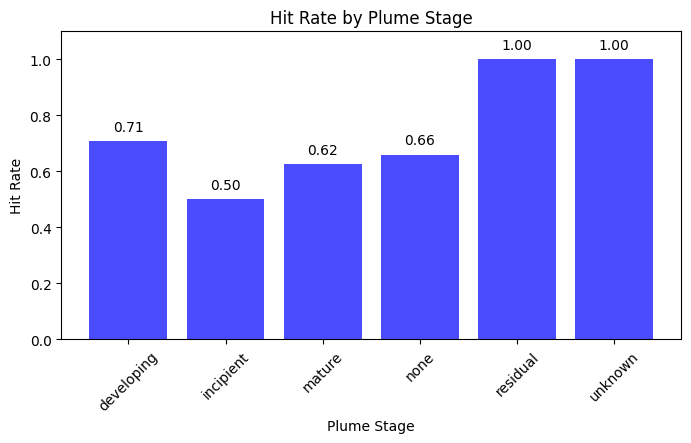

In [165]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='hit_rate', title='Hit Rate by Plume Stage', ylabel='Hit Rate', xlabel='Plume Stage')

### NDCG

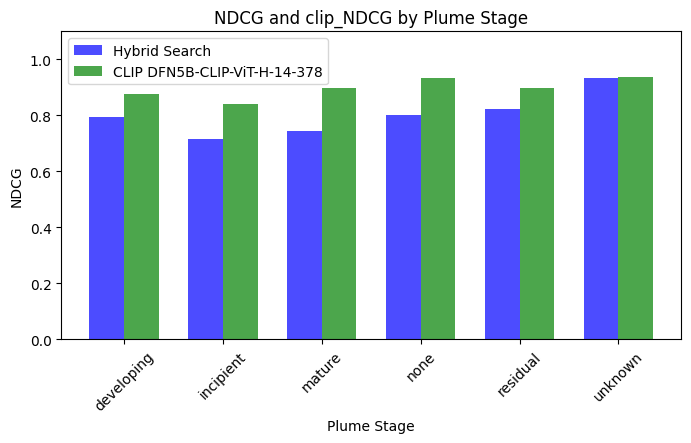

In [166]:
plot_rank_comparison(plume_stage_metrics, x_column='plume_stage', title='NDCG and clip_NDCG by Plume Stage', xlabel='Plume Stage')

### MRR

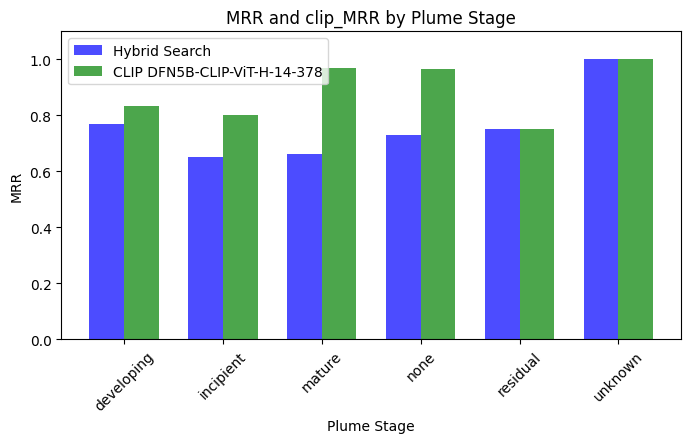

In [167]:
plot_rank_comparison(plume_stage_metrics, x_column='plume_stage', title='MRR and clip_MRR by Plume Stage', xlabel='Plume Stage', metric="MRR")

## Metrics based on Viewpoint

In [168]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,aerial,300,57,243,40,260,0.190000,0.133333,0.282651,0.916667,0.806650,0.904843,0.783333,0.875000
1,fixed_long_range,1975,141,1834,102,1873,0.071392,0.051646,0.094854,0.632911,0.796195,0.911903,0.736498,0.922363
2,handheld,225,18,207,12,213,0.080000,0.053333,0.092224,0.666667,0.701160,0.903514,0.587037,1.000000


### Accuracy

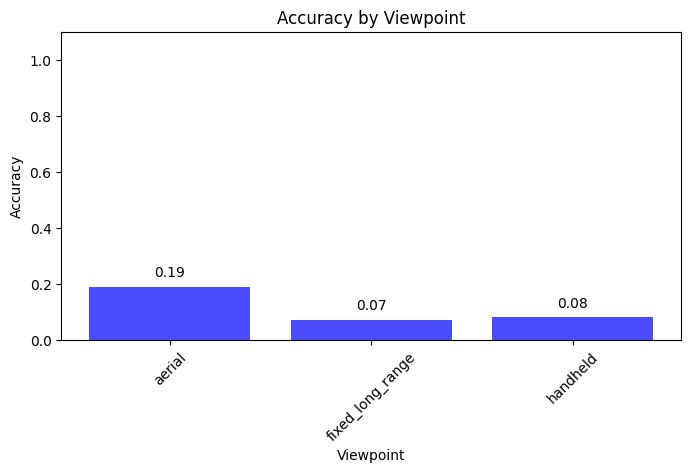

In [169]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

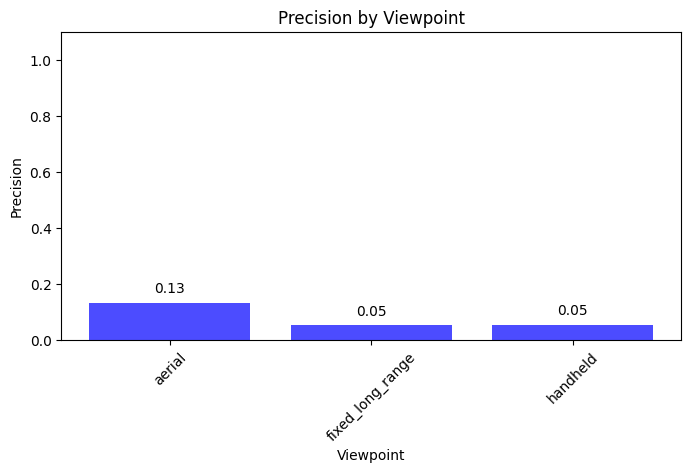

In [170]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

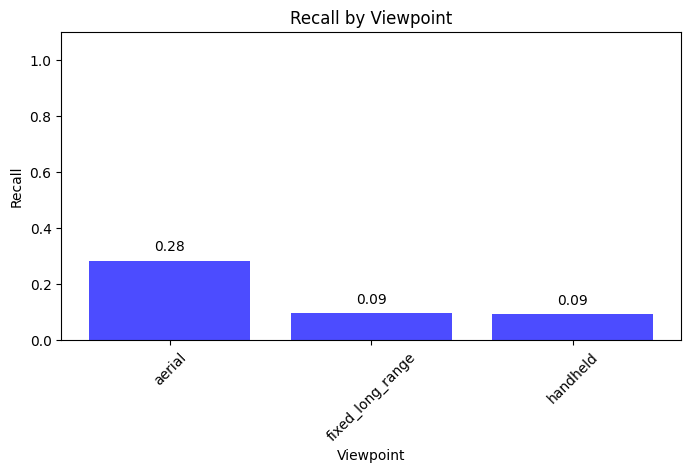

In [171]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

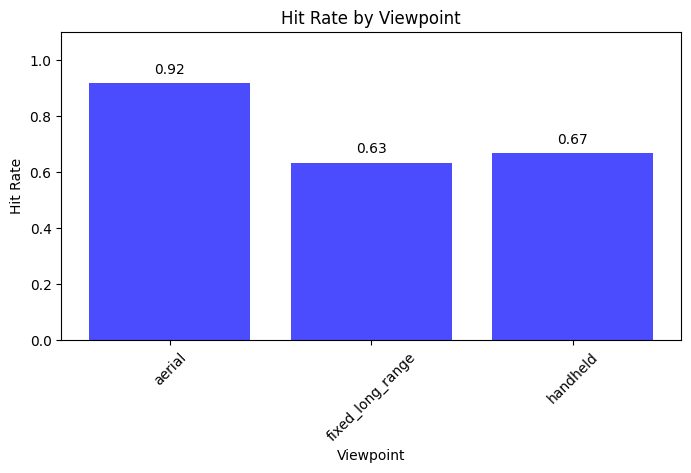

In [172]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### NDCG

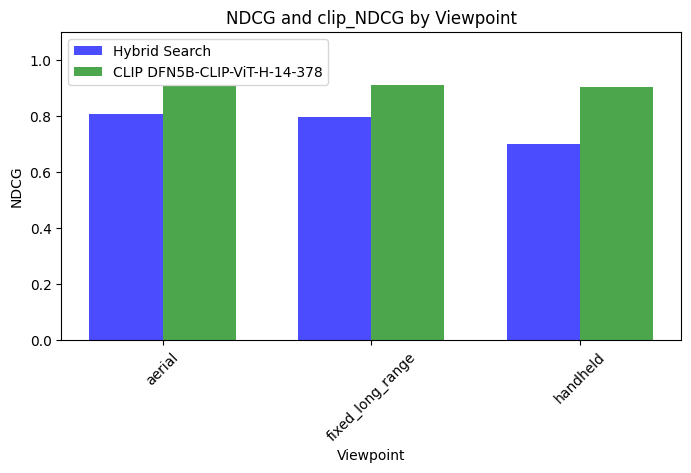

In [173]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

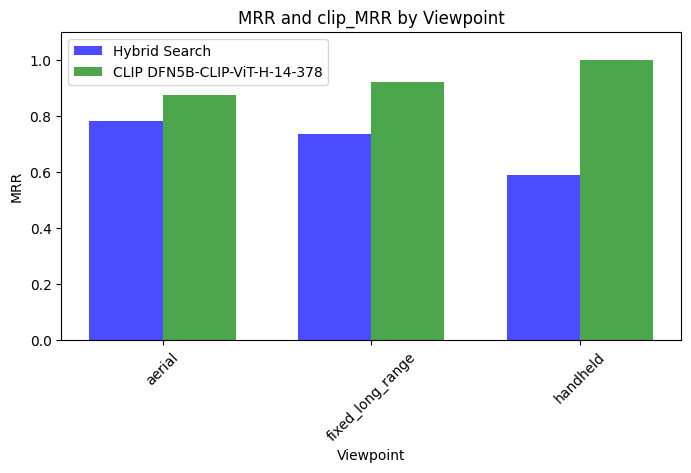

In [174]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Lighting & Flame Visible

Here we will group by Lighting and Flame Visible and calculate the sum/mean of each metric to see how the system performs under different lighting and flame visible conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [175]:
# Group by Lighting and Flame Visible and calculate the sum/mean of each metric
lighting_flame_visible_metrics = df.groupby(['lighting', 'flame_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean'
}).reset_index()
lighting_flame_visible_metrics['flame_visible'] = lighting_flame_visible_metrics['flame_visible'].map({True: 'True', False: 'False'})

#rename columns
lighting_flame_visible_metrics = lighting_flame_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_flame_visible_metrics

,lighting,flame_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR
0,day,False,1875,132,1743,98,1777,0.070400,0.052267,0.100166,0.640000,0.800285,0.919662,0.736593,0.940000
1,day,True,100,16,84,11,89,0.160000,0.110000,0.195318,0.750000,0.692865,0.928488,0.487500,1.000000
2,dusk,False,175,27,148,19,156,0.154286,0.108571,0.214613,1.000000,0.748705,0.857051,0.687302,0.814286
3,dusk,True,25,4,21,1,24,0.160000,0.040000,0.250000,1.000000,0.666364,0.678660,1.000000,0.500000
4,ir_nir,False,75,1,74,0,75,0.013333,0.000000,0.000000,0.000000,0.900023,0.790531,1.000000,0.555556
5,night,False,225,32,193,23,202,0.142222,0.102222,0.157701,0.777778,0.773141,0.921323,0.706790,1.000000
6,night,True,25,4,21,2,23,0.160000,0.080000,0.250000,1.000000,0.531193,1.000000,0.500000,1.000000


In [176]:
# Define colors for each supercategory
fl_colors = {
    "True": "red",
    "False": "green",
}

# Assign colors based on supercategory
colors = [fl_colors[sc] for sc in lighting_flame_visible_metrics['flame_visible']]

### Accuracy

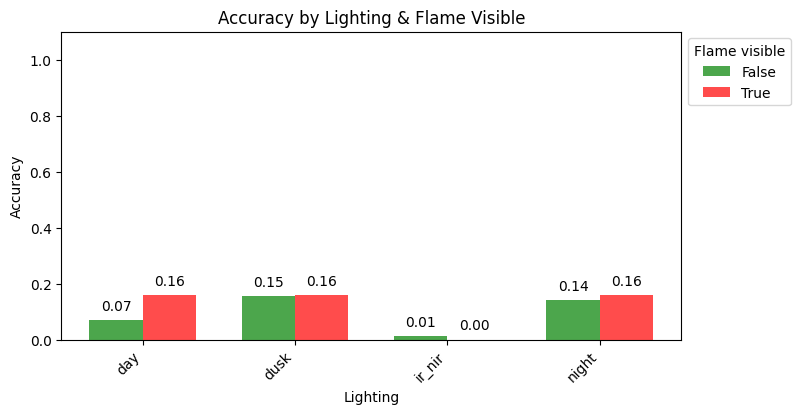

In [177]:
# Accuracy by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='accuracy', 
    color_map=fl_colors, 
    ylabel="Accuracy", 
    xlabel="Lighting", 
    title="Accuracy by Lighting & Flame Visible",
)

### Precision

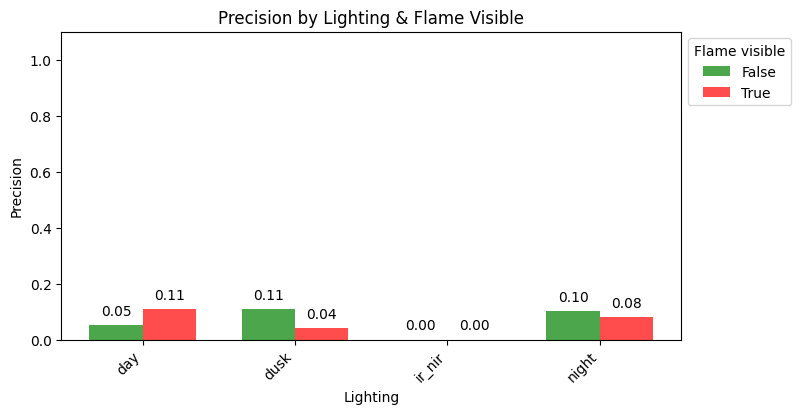

In [178]:
# Precision by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='precision', 
    color_map=fl_colors, 
    ylabel="Precision", 
    xlabel="Lighting", 
    title="Precision by Lighting & Flame Visible",
)

### Recall

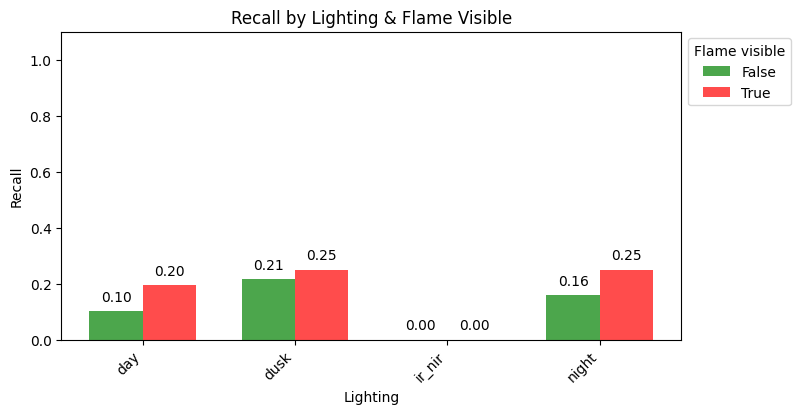

In [179]:
# Recall by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='recall', 
    color_map=fl_colors,
    ylabel="Recall", 
    xlabel="Lighting", 
    title="Recall by Lighting & Flame Visible",
)


### Hit Rate

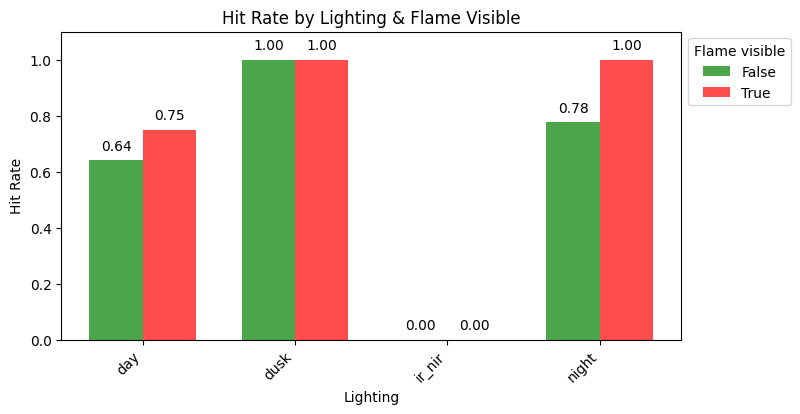

In [180]:
# Recall by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='hit_rate', 
    color_map=fl_colors,
    ylabel="Hit Rate", 
    xlabel="Lighting", 
    title="Hit Rate by Lighting & Flame Visible",
)

### NDCG

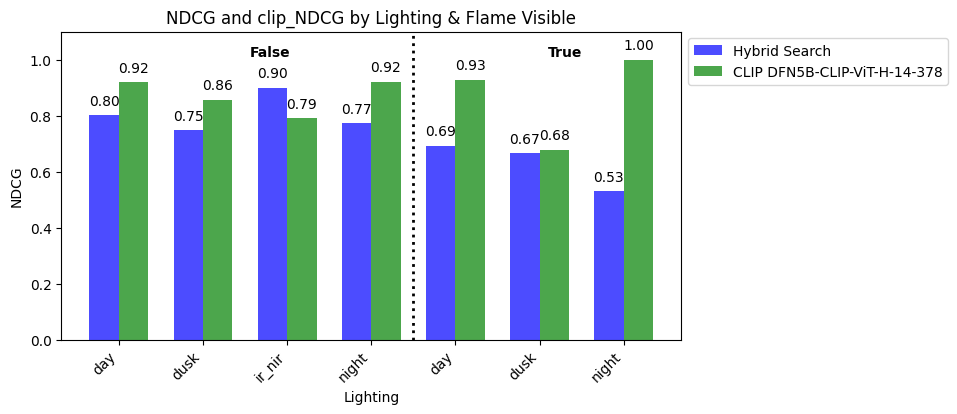

In [181]:
# Sort by flame_visible so group dividers and labels are correct
_ndcg_df = lighting_flame_visible_metrics.sort_values("flame_visible").reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column="lighting",
    group_column="flame_visible",
    title="NDCG and clip_NDCG by Lighting & Flame Visible",
    xlabel="Lighting",
)


### MRR

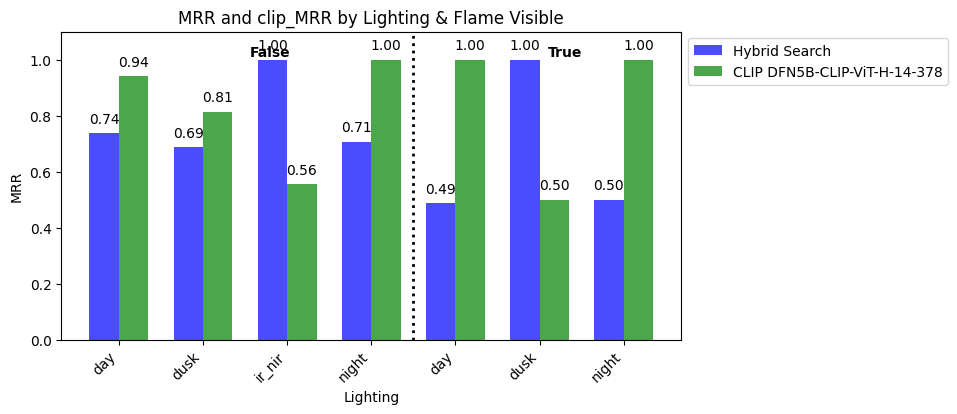

In [182]:
# Sort by flame_visible so group dividers and labels are correct
_mrr_df = lighting_flame_visible_metrics.sort_values("flame_visible").reset_index(drop=True)
plot_multi_rank_comparison(
    _mrr_df,
    x_column="lighting",
    group_column="flame_visible",
    title="MRR and clip_MRR by Lighting & Flame Visible",
    xlabel="Lighting",
    metric="MRR"
)

## Insights & Conclusion

---

**Overall Metrics Summary**

| System                   | v10 (NRP Gemma-3-27B + DFN5B-CLIP) |
| ------------------------ | ------------------------------------------- |
| **Total Images**         | 2,500                                       |
| **Correctly Returned**   | 216                                         |
| **Incorrectly Returned** | 2,284                                      |
| **Relevant Images**      | 154                                       |
| **Accuracy**             | 0.0864 (8.64%)                              |
| **Precision**            | 0.0616 (6.16%)                              |
| **Recall**               | 0.1172 (11.72%)                             |
| **Hit Rate**             | 0.67 (67%)                              |
| **NDCG**                 | 0.7889                                      |
| **clip_NDCG**            | 0.9103                                      |
| **MRR**                  | 0.7287                              |
| **clip_MRR**             | 0.9237                                      |

---

**Interpretation**

* **Accuracy (8.64%)** is low: only a small share of returned images match the query ID in the dataset. This is expected when many queries describe subtle or specific wildfire conditions (e.g., plume stage, confounders) and the pool is large and diverse.
* **Precision (6.16%)** indicates that a small fraction of returned images are relevant to the query; the system tends to return many non-relevant images per query.
* **Recall (11.72%)** shows that the system retrieves about 11% of the relevant images in the dataset per query on average—room to improve coverage of relevant fire imagery.
* **NDCG (0.79)** is below **clip_NDCG (0.91)**, so the ms-marco-MiniLM-L6-v2 reranker model ranks results worse than the CLIP-only baseline in the dataset. The **CLIP (DFN5B-CLIP-ViT-H-14-378)** scores in the dataset are able to rank results better than the reranker model (ms-marco-MiniLM-L6-v2) used in the image search system; it may be worth looking into using this model as the reranker.
* **Hit Rate (67%)** indicates 67% of queries had at least one relevant image in the top results (e.g., top 25). A higher hit rate means users are more likely to see at least one relevant result; breakdowns by environment, confounder, lighting, and other axes show where the system succeeds or fails to surface any relevant image.
* **MRR (0.73)** measures how early the first relevant result appears. **MRR** below **clip_MRR (0.92)** means that under the current reranker, the first relevant result tends to appear later in the list than under the dataset's CLIP ranking—consistent.

---

**Insights**

* **Environment type:** Performance varies by environment (coastal, forest, grassland, mountainous). Mountainous and forest queries account for most of the volume; accuracy and recall are generally low across environments, with coastal showing the highest accuracy in the breakdown.
* **Confounders:** Queries with **fog/marine layer** or **haze** tend to behave differently from **none** or **cloud**; confounder-heavy conditions are a useful axis to track for robustness.
* **Lighting:** Daytime queries dominate. Dusk shows higher accuracy and recall than day in the breakdown; IR/NIR has very few queries and the lowest metrics.
* **Flame visible:** Most queries have no visible flames (False). When flames are visible (True), accuracy and recall are higher, but the number of such queries is small.
* **Plume stage & viewpoint:** Developing and mature plumes, and fixed long-range viewpoints, account for most of the data; incipient and handheld show lower metrics in the breakdowns.

---

**Conclusion**

This **v10** Firebench run establishes a **baseline** for the image search pipeline using **NRP's gemma-3-27b-it**, **DFN5B-CLIP-ViT-H-14-378**, and **ms-marco-MiniLM-L6-v2** reranking (production config: **response_limit=25**). Overall **accuracy** and **precision** are low (9.04% and 6.44%), while **recall** (11.48%), **NDCG** (0.78), **hit rate**, and **MRR** summarize retrieval and ranking: hit rate shows how often at least one relevant result appears in the top results, and MRR reflects how early that first relevant result appears. **clip_NDCG** and **clip_MRR** both exceed the reranker’s **NDCG** and **MRR**, so the dataset’s **CLIP (DFN5B-CLIP-ViT-H-14-378)** ranking outperforms the current reranker; it may be worth considering this model as the reranker in the image search system. Breaking down by **environment**, **confounder**, **lighting**, **flame_visible**, **plume_stage**, and **viewpoint** shows where the system is stronger (e.g., flame-visible, dusk, coastal) and where it is weaker (e.g., IR/NIR, incipient plume).

Because Firebench does not yet have a leaderboard or prior published runs, this notebook serves as a **reference run** for future comparisons and for improving wildfire image retrieval and ranking.
